## Imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import scipy.linalg as linalg

## Part 2

#### Task 9

#### Defining parameters

In [15]:
n_women = 1000

Q = np.array([
    [-0.0085, 0.005,  0.0025, 0.000, 0.001],
    [ 0.0000,-0.014,  0.0050, 0.004, 0.005],
    [ 0.0000, 0.000, -0.0080, 0.003, 0.005],
    [ 0.0000, 0.000,  0.0000,-0.009, 0.009],
    [ 0.0000, 0.000,  0.0000, 0.000, 0.000]
])

Q_treatment = np.array([
    [-0.00475, 0.0025, 0.00125, 0.000, 0.001],
    [ 0.00000,-0.0070, 0.00000, 0.002, 0.005],
    [ 0.00000, 0.0000,-0.00800, 0.003, 0.005],
    [ 0.00000, 0.0000, 0.00000,-0.009, 0.009],
    [ 0.00000, 0.0000, 0.00000, 0.000, 0.000]
])

def simulate_one_woman_ctmc(Q):
    current_state = 1
    time = 0.0
    path = [(time, current_state)]

    while current_state != 5:
        row = Q[current_state - 1]

        rate = -row[current_state - 1]

        waiting_time = np.random.exponential(scale= 1/rate)
        time += waiting_time

        jump_rates = row.copy()
        jump_rates[current_state - 1] = 0

        probabilities = jump_rates / rate

        next_state = np.random.choice(np.array([1, 2, 3, 4, 5]),p=probabilities)

        current_state = next_state
        path.append((time, current_state))

    return time, path

lifetimes_ctmc = []
paths_ctmc = []

for _ in range(n_women):
    lifetime, path = simulate_one_woman_ctmc(Q)
    lifetimes_ctmc.append(lifetime)
    paths_ctmc.append(path)

lifetimes_ctmc = np.array(lifetimes_ctmc)

In [16]:
def death(t, paths):
    death_count = 0

    for path in paths:
        is_dead = False

        for time, state in path:
            if time < t and state == 5:
                is_dead = True
                break

        if is_dead:
            death_count += 1

    return death_count


def kaplan_meier(t, paths):
    N = len(paths)
    return (N - death(t, paths)) / N





In [17]:



lifetimes_treatment = []
paths_treatment = []

for _ in range(n_women):
    lifetime, path = simulate_one_woman_ctmc(Q_treatment)
    lifetimes_treatment.append(lifetime)
    paths_treatment.append(path)

lifetimes_treatment = np.array(lifetimes_treatment)

death(230, paths_treatment)

376

In [18]:
max_time = max(np.max(lifetimes_ctmc), np.max(lifetimes_treatment))
times = np.linspace(0, max_time, 500)

S_no_treatment = np.array([kaplan_meier(t, paths_ctmc)for t in times])

S_treatment = np.array([kaplan_meier(t, paths_treatment)for t in times])

#### Plot

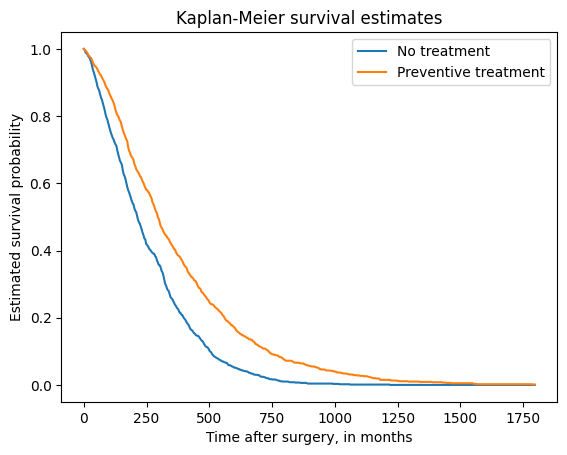

In [233]:
plt.plot(times, S_no_treatment, label="No treatment")
plt.plot(times, S_treatment, label="Preventive treatment")

plt.xlabel("Time after surgery, in months")
plt.ylabel("Estimated survival probability")
plt.title("Kaplan-Meier survival estimates")
plt.legend()
plt.show()

### Task 10

#### Log rank test

In [ ]:
def log_rank_test(lifetimes_1, lifetimes_2):

    lifetimes_1 = np.array(lifetimes_1)
    lifetimes_2 = np.array(lifetimes_2)

    # All unique death times
    event_times = np.sort(np.unique(np.concatenate([lifetimes_1, lifetimes_2])))

    O1_total = 0
    E1_total = 0
    V1_total = 0

    n1 = len(lifetimes_1)
    n2 = len(lifetimes_2)

    for t in event_times:
        # Number at risk just before time t
        Y1 = np.sum(lifetimes_1 >= t)
        Y2 = np.sum(lifetimes_2 >= t)
        Y = Y1 + Y2

        # Number of deaths at time t
        d1 = np.sum(lifetimes_1 == t)
        d2 = np.sum(lifetimes_2 == t)
        d = d1 + d2

        if Y <= 1:
            continue

        # Observed deaths in group 1
        O1_total += d1

        # Expected deaths in group 1 under equal survival functions
        E1_total += d * (Y1 / Y)

        # Variance contribution
        V1_total += ((Y1 * Y2 * d * (Y - d)) /(Y**2 * (Y - 1)))

    test_statistic = (O1_total - E1_total)**2 / V1_total

    #if i use cdf i get p = 0 in the final result so use sf instead
    p_value = stats.chi2.sf(test_statistic, df=1)

    return test_statistic, p_value

In [20]:
test_statistic, p_value = log_rank_test(lifetimes_ctmc, lifetimes_treatment)

print("Log-rank test statistic:", test_statistic)
print("p-value:", p_value)


Log-rank test statistic: 69.9045940007264
p-value: 6.224331816587665e-17
